# Row 4: Spot crossing the flip level intraday changes the rest of the day

| field | content |
|---|---|
| frequency (GEX period) | live value at a 30-minute close |
| strength | 0.45 (crossing down) and 0.31 (crossing up), point-biserial correlation |
| tradability (1 to 10) | 6 |
| holds for | yes SPY and QQQ (0.97 versus 1.21 crossing up, 1.13 versus 0.82 crossing down); direction only IWM; TSLA crossing down only (11 events); no META, MSFT; too few events in NVDA, AAPL, AMZN, AMD |
| how to trade | crossing up: fade volatility and sell premium; crossing down: buy protection and widen stops |
| numbers (SPY) | 29% of days cross, 13% by 10:00; among days that started within 0.5% of the flip, crossing up 0.97 versus staying 1.24 times the median, crossing down 1.12 versus 0.81; both confidence intervals exclude zero |
| example | 2024-11-21: prior close +0.7 billion dollars, crossed down at 10:30, rest of day 1.39 times the median. 2026-07-09: prior close -3.7 billion, crossed up at 10:00, rest of day 0.74 times |
| video opener | There is a price level, the gamma flip, where dealer hedging switches from calming the market to chasing it. When SPY crosses that level during the day, the rest of the session gets quieter after an upward cross and wilder after a downward one. Watch the live flip level and adjust your risk when price goes through it, instead of waiting for tomorrow's report. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "share_days_flipped": 0.29071332436069985,
 "first_flip_bucket_counts": {
  "0.0": 100,
  "1.0": 22,
  "2.0": 16,
  "3.0": 11,
  "4.0": 14,
  "5.0": 8,
  "6.0": 9,
  "7.0": 5,
  "8.0": 7,
  "9.0": 7,
  "10.0": 4,
  "11.0": 10,
  "12.0": 3
 },
 "matched_on_move_size": {
  "neg_to_pos": {
   "n_flip_days": 117,
   "n_noflip_days": 309,
   "post_flip_minus_reference_unmatched": -0.6016589451044501,
   "ci_unmatched": [
    -0.6853046278384147,
    -0.5090226278850992
   ],
   "post_flip_minus_reference_matched": -0.6380877035273889,
   "ci_matched": [
    -0.7213440773596359,
    -0.548404651994762
   ],
   "n_matched": 117
  },
  "pos_to_neg": {
   "n_flip_days": 86,
   "n_noflip_days": 218,
   "post_flip_minus_reference_unmatched": 0.3314893367476639,
   "ci_unmatched": [
    0.22378054087088814,
    0.4566140270017859
   ],
   "post_flip_minus_reference_matched": 0.3134313631816619,
   "ci_matched": [
    0.20734550220062478,
    0.44130740150037623
   ],
   "n_matched": 86
  }
 },


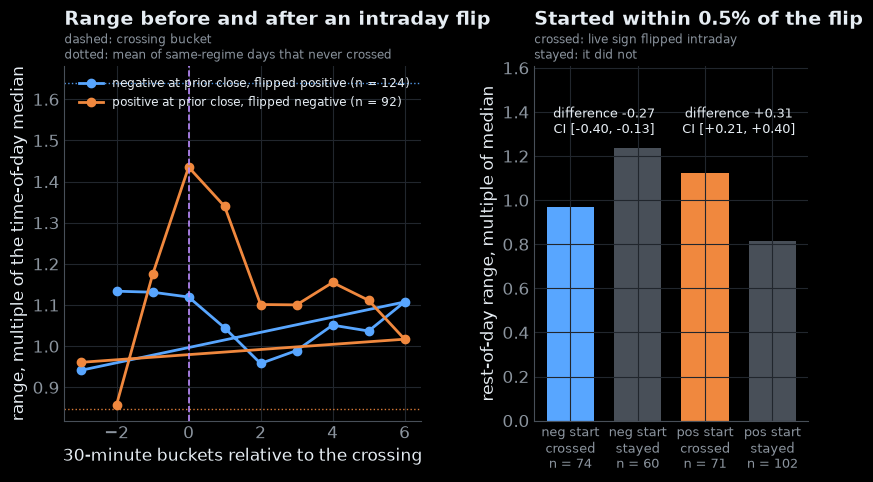

In [2]:
res = R.row4(ctx)
print(json.dumps(R.show(res), indent=1))
_ = R.fig4(ctx, res, G.FIGURES / 'row04_flip_crossing.png')

In [3]:
R.per_name({'r4_up_cross': 'crossed up, rest-of-day range', 'r4_up_stay': 'stayed, rest-of-day range', 'r4_up_n': 'count crossed up', 'r4_up_ci_excl0': 'confidence interval excludes zero (up)', 'r4_down_cross': 'crossed down, rest-of-day range', 'r4_down_stay': 'stayed', 'r4_down_n': 'count crossed down', 'r4_down_ci_excl0': 'confidence interval excludes zero (down)'}).round(3)

,"crossed up, rest-of-day range","stayed, rest-of-day range",count crossed up,confidence interval excludes zero (up),"crossed down, rest-of-day range",stayed,count crossed down,confidence interval excludes zero (down)
symbol,,,,,,,,
SPY,1.008,1.252,102,True,1.151,0.842,85,True
QQQ,0.975,1.212,22,True,1.127,0.816,19,True
IWM,0.965,1.117,23,False,1.046,1.079,16,False
NVDA,NaN,NaN,3,None,NaN,NaN,5,None
TSLA,NaN,NaN,7,None,1.090,0.838,11,True
AAPL,NaN,NaN,3,None,NaN,NaN,2,None
AMZN,NaN,NaN,4,None,NaN,NaN,7,None
META,1.163,1.131,11,False,0.963,1.008,13,False
MSFT,1.232,1.347,7,False,1.180,1.069,13,False
